# Fase 1: Predicción del GRD (Diagnosis-Related Groups)
## Hospital El Pino - Machine Learning

### CINF104 - Aprendizaje de Máquinas | Universidad Andrés Bello | 2026

### **Integrantes:**

Jaime Arriagada

Nicolás Barrientos

Benjamín Garat

Matías Palma

### **Profesor:** Pablo Schwarzenberg

### **NRC:** 7917

### **Objetivo:**

Construir un predictor del GRD a partir de la información disponible de los pacientes del Hospital El Pino (diagnósticos ICD-10, procedimientos ICD-9, edad y sexo).

### **Estructura del notebook:**
1. Instalación y configuración
2. Carga del dataset
3. Exploración inicial
4. Análisis de calidad de datos (completitud, correctitud, outliers)
5. Análisis de variables demográficas
6. Análisis de la variable objetivo (GRD)
7. Extracción y análisis de códigos ICD
8. Vista previa de features para el modelo

---
## Sección 1: Instalación y Configuración

In [112]:
# Instalar dependencias
!pip install pandas numpy matplotlib seaborn -q

In [113]:
# Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'primary': '#2E5FA3', 'secondary': '#E74C3C', 'accent': '#27AE60', 'neutral': '#95A5A6'}
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 12, 'axes.titlesize': 13,
                     'axes.labelsize': 12, 'figure.dpi': 120})

# Directorios de salida
IMAGES_DIR = 'assets/images'
os.makedirs(IMAGES_DIR, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

MISSING_SENTINEL = {'-', '—', 'nan', 'None', '', 'NaN', 'n/a', 'N/A'}

def extract_icd_code(value: str) -> str | None:
    """Extrae el código ICD completo de una celda con formato 'CÓDIGO - Descripción'."""
    if pd.isna(value):
        return None
    s = str(value).strip()
    if s in MISSING_SENTINEL:
        return None
    code_part = s.split(' - ')[0].strip() if ' - ' in s else s
    match = re.match(r'^[A-Z0-9]+\.?\d*', code_part)
    return match.group(0) if match else None

print("Configuración completada")
print(f"Imágenes: {IMAGES_DIR}")

Configuración completada
Imágenes: assets/images


---
## Sección 2 - Carga del Dataset

In [114]:
DATA_PATH = 'dataset_elpino.csv'

df = pd.read_csv(DATA_PATH, sep=';')

print(f"Dataset cargado exitosamente")
print(f"  Filas    : {df.shape[0]:,}")
print(f"  Columnas : {df.shape[1]}")
df.head(3)

Dataset cargado exitosamente
  Filas    : 14,561
  Columnas : 68


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...


---
## Sección 3 - Exploración Inicial

In [115]:
# Identificar columnas por tipo
diagnosis_cols  = [c for c in df.columns if 'Diag' in c]
procedure_cols  = [c for c in df.columns if 'Proced' in c]
demo_cols       = ['Edad en años', 'Sexo (Desc)']
target_col      = 'GRD'

print("ESTRUCTURA DEL DATASET: \n")
print(f"Columnas de diagnóstico: {len(diagnosis_cols)}")
print(f"Columnas de procedimiento: {len(procedure_cols)}")
print(f"Columnas demográficas: {demo_cols}")
print(f"Variable objetivo: {target_col} \n")
print()
print("Tipos de datos:")
print(df.dtypes.value_counts(), "\n")
print("Muestra de columnas:")
print(df.columns.tolist())

ESTRUCTURA DEL DATASET: 

Columnas de diagnóstico: 35
Columnas de procedimiento: 30
Columnas demográficas: ['Edad en años', 'Sexo (Desc)']
Variable objetivo: GRD 


Tipos de datos:
object    67
int64      1
Name: count, dtype: int64 

Muestra de columnas:
['Diag 01 Principal (cod+des)', 'Diag 02 Secundario (cod+des)', 'Diag 03 Secundario (cod+des)', 'Diag 04 Secundario (cod+des)', 'Diag 05 Secundario (cod+des)', 'Diag 06 Secundario (cod+des)', 'Diag 07 Secundario (cod+des)', 'Diag 08 Secundario (cod+des)', 'Diag 09 Secundario (cod+des)', 'Diag 10 Secundario (cod+des)', 'Diag 11 Secundario (cod+des)', 'Diag 12 Secundario (cod+des)', 'Diag 13 Secundario (cod+des)', 'Diag 14 Secundario (cod+des)', 'Diag 15 Secundario (cod+des)', 'Diag 16 Secundario (cod+des)', 'Diag 17 Secundario (cod+des)', 'Diag 18 Secundario (cod+des)', 'Diag 19 Secundario (cod+des)', 'Diag 20 Secundario (cod+des)', 'Diag 21 Secundario (cod+des)', 'Diag 22 Secundario (cod+des)', 'Diag 23 Secundario (cod+des)', 'Diag 24

---
## Sección 4 — Análisis de Calidad de Datos
### 4.1 Completitud · 4.2 Correctitud · 4.3 Outliers

Total de celdas con valores faltantes: 649,545
Completitud Dx. Principal : 100.0%
Completitud P. Principal  : 100.0%


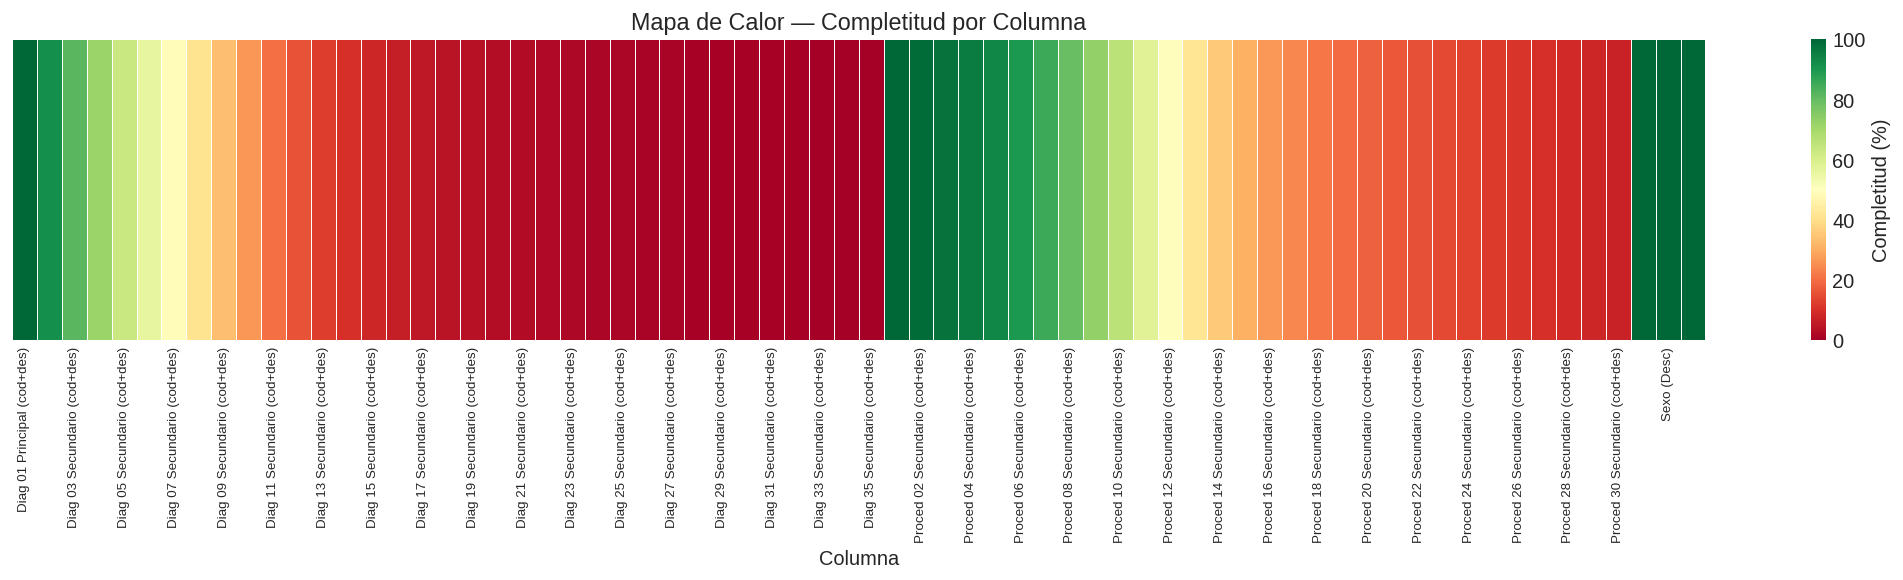

Guardado: assets/images/01_completeness.png


In [116]:
# 4.1 Completitud
def completeness_pct(series: pd.Series) -> float:
    """Porcentaje de valores no faltantes en una Serie."""
    valid = series.apply(lambda x: str(x).strip() not in MISSING_SENTINEL and pd.notna(x))
    return valid.sum() / len(series) * 100

completeness = {col: completeness_pct(df[col]) for col in df.columns}
comp_df = pd.DataFrame({'Columna': list(completeness.keys()),
                        'Completitud_%': list(completeness.values())})

total_missing = sum(
    1 for col in df.columns
    for v in df[col]
    if pd.isna(v) or str(v).strip() in MISSING_SENTINEL
)

print(f"Total de celdas con valores faltantes: {total_missing:,}")
print(f"Completitud Dx. Principal : {completeness[diagnosis_cols[0]]:.1f}%")
print(f"Completitud P. Principal  : {completeness[procedure_cols[0]]:.1f}%")

# Visualización: heatmap de completitud
fig, ax = plt.subplots(figsize=(18, 5))
heatmap_vals = comp_df.set_index('Columna')[['Completitud_%']].T
sns.heatmap(heatmap_vals, annot=False, cmap='RdYlGn', vmin=0, vmax=100,
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Completitud (%)'})
ax.set_title('Mapa de Calor — Completitud por Columna', fontsize=14)
ax.set_yticklabels([])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/01_completeness.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: {IMAGES_DIR}/01_completeness.png")

In [117]:
# 4.2 Correctitud — validación de códigos ICD y edad
ICD10_PATTERN = re.compile(r'^[A-Z]\d{2}(\.\d{1,2})?$')
ICD9_PATTERN  = re.compile(r'^\d{2,3}(\.\d{1,2})?$|^[VE]\d{2}(\.\d{1,2})?$')

def pct_valid_codes(series, pattern):
    """Porcentaje de entradas no faltantes cuyo código extraído coincide con el patrón ICD."""
    extracted = series.apply(extract_icd_code)
    non_missing = extracted.dropna()
    if len(non_missing) == 0:
        return 0.0
    valid = non_missing.apply(lambda x: bool(pattern.match(str(x).strip())))
    return valid.mean() * 100

print("=" * 55)
print("VALIDACIÓN DE CORRECTITUD DE CÓDIGOS ICD")
print("=" * 55)

# Validación ICD-10 (diagnósticos)
diag_pcts = []
for col in diagnosis_cols:
    pct = pct_valid_codes(df[col], ICD10_PATTERN)
    diag_pcts.append(pct)

# Validación ICD-9 (procedimientos)
proc_pcts = []
for col in procedure_cols:
    pct = pct_valid_codes(df[col], ICD9_PATTERN)
    proc_pcts.append(pct)

avg_diag = sum(diag_pcts) / len(diag_pcts)
avg_proc = sum(proc_pcts) / len(proc_pcts)

print(f"  ICD-10 (Diagnósticos)   → {avg_diag:.1f}% válidos en promedio")
print(f"  ICD-9  (Procedimientos) → {avg_proc:.1f}% válidos en promedio")

# Tabla resumen
correctitud_df = pd.DataFrame({
    'Tipo de Código': ['ICD-10 (Diagnósticos)', 'ICD-9 (Procedimientos)'],
    'Porcentaje Válido (%)': [round(avg_diag, 1), round(avg_proc, 1)]
})
print("\n")
print(correctitud_df.to_string(index=False))

# Verificar duplicados
n_dup = df.duplicated().sum()
print(f"\nRegistros duplicados: {n_dup}")

VALIDACIÓN DE CORRECTITUD DE CÓDIGOS ICD
  ICD-10 (Diagnósticos)   → 100.0% válidos en promedio
  ICD-9  (Procedimientos) → 100.0% válidos en promedio


        Tipo de Código  Porcentaje Válido (%)
 ICD-10 (Diagnósticos)                  100.0
ICD-9 (Procedimientos)                  100.0

Registros duplicados: 144


Análisis de outliers en Edad:
  Q1=23.0, Q3=60.0, IQR=37.0
  Límite inferior: -32.5 | Límite superior: 115.5
  Outliers detectados: 1 (0.0%)
  Edades > 100: 2 pacientes
  Valor máximo: 121 años
  → Los outliers se retienen (pueden ser clínicamente válidos).


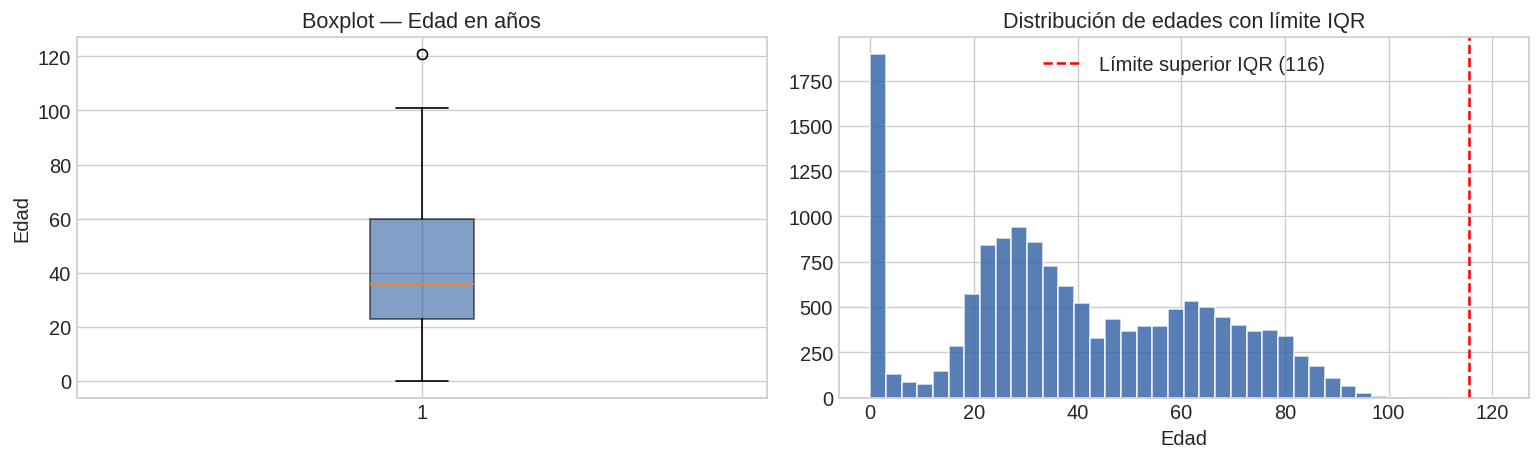

In [118]:
# 4.3 Outliers — variable edad
df['Edad en años'] = pd.to_numeric(df['Edad en años'], errors='coerce')

age = df['Edad en años'].dropna()
Q1, Q3 = age.quantile(0.25), age.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = age[(age < lower_fence) | (age > upper_fence)]

print(f"Análisis de outliers en Edad:")
print(f"  Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}")
print(f"  Límite inferior: {lower_fence:.1f} | Límite superior: {upper_fence:.1f}")
print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(age)*100:.1f}%)")
print(f"  Edades > 100: {(age > 100).sum()} pacientes")
print(f"  Valor máximo: {age.max():.0f} años")
print("  → Los outliers se retienen (pueden ser clínicamente válidos).")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].boxplot(age, vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE['primary'], alpha=0.6))
axes[0].set_title('Boxplot — Edad en años'); axes[0].set_ylabel('Edad')
axes[1].hist(age, bins=40, color=PALETTE['primary'], edgecolor='white', alpha=0.8)
axes[1].axvline(upper_fence, color='red', linestyle='--', label=f'Límite superior IQR ({upper_fence:.0f})')
axes[1].set_title('Distribución de edades con límite IQR')
axes[1].set_xlabel('Edad'); axes[1].legend()
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/02_outliers_age.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Sección 5 — Estadísticas Descriptivas y Variables Demográficas

ESTADÍSTICAS DESCRIPTIVAS — EDAD
count    14561.000000
mean        39.426550
std         24.681545
min          0.000000
25%         23.000000
50%         36.000000
75%         60.000000
max        121.000000

DISTRIBUCIÓN POR SEXO
  Mujer: 9,617 (66.0%)
  Hombre: 4,944 (34.0%)


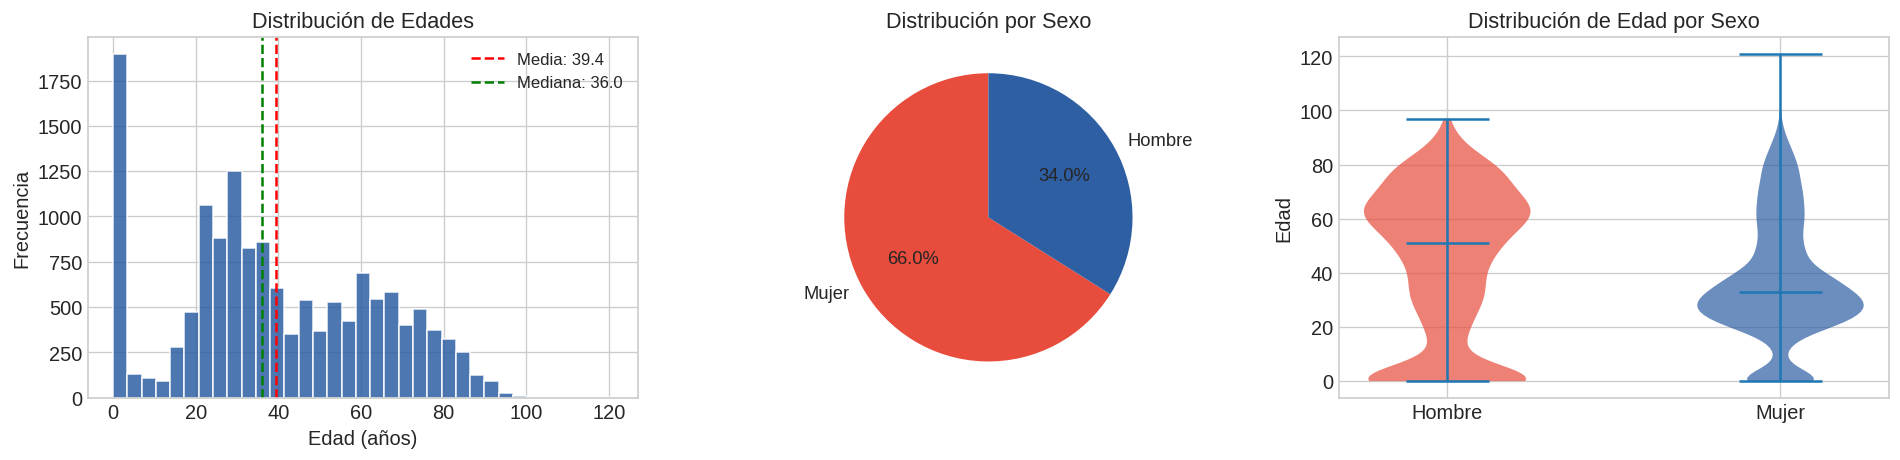

Guardado: assets/images/03_demographics.png


In [119]:
# Estadísticas de edad
print("ESTADÍSTICAS DESCRIPTIVAS — EDAD")
print(df['Edad en años'].describe().to_string())

sex_counts = df['Sexo (Desc)'].value_counts()
print("\nDISTRIBUCIÓN POR SEXO")
for s, n in sex_counts.items():
    print(f"  {s}: {n:,} ({n/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma de edades
axes[0].hist(df['Edad en años'].dropna(), bins=35,
             color=PALETTE['primary'], edgecolor='white', alpha=0.85)
axes[0].axvline(df['Edad en años'].mean(), color='red',   ls='--', label=f'Media: {df["Edad en años"].mean():.1f}')
axes[0].axvline(df['Edad en años'].median(), color='green', ls='--', label=f'Mediana: {df["Edad en años"].median():.1f}')
axes[0].set_title('Distribución de Edades'); axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia'); axes[0].legend(fontsize=10)

# Gráfico de torta por sexo
colors_sex = [PALETTE['secondary'], PALETTE['primary']]
axes[1].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%',
            colors=colors_sex, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Distribución por Sexo')

# Distribución de edad por sexo (violin plot)
df_sex_age = df[['Edad en años', 'Sexo (Desc)']].dropna()
groups = [df_sex_age[df_sex_age['Sexo (Desc)'] == s]['Edad en años'].values
          for s in df_sex_age['Sexo (Desc)'].unique()]
labels = df_sex_age['Sexo (Desc)'].unique().tolist()
vp = axes[2].violinplot(groups, showmedians=True)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(colors_sex[i % 2]); body.set_alpha(0.7)
axes[2].set_xticks(range(1, len(labels)+1)); axes[2].set_xticklabels(labels)
axes[2].set_title('Distribución de Edad por Sexo'); axes[2].set_ylabel('Edad')

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/03_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: {IMAGES_DIR}/03_demographics.png")

---
## Sección 6 — Análisis de la Variable Objetivo (GRD)

Clases GRD únicas       : 526
Clase más frecuente     : '146101 - PH CESÁREA' (813 muestras)
Clase menos frecuente   : 1 muestras
Ratio de desbalanceo    : 813:1
Clases con solo 1 muestra: 76 (14.4%)
Clases con < 10 muestras : 297 (56.5%)


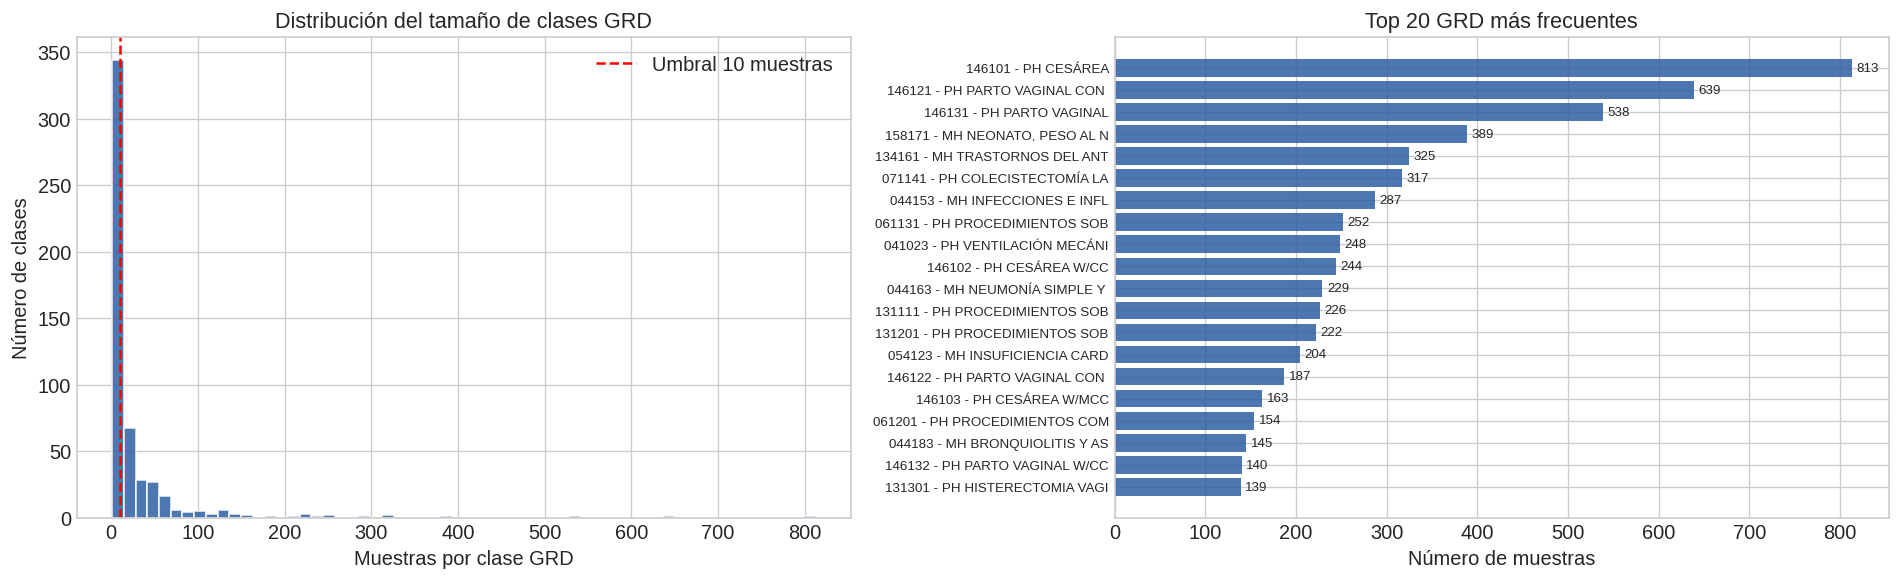

Guardado: assets/images/04_grd_distribution.png


In [121]:
# Distribución GRD
grd_counts = df['GRD'].value_counts()
n_classes  = len(grd_counts)
max_class  = grd_counts.index[0]
max_count  = grd_counts.iloc[0]
min_count  = grd_counts.iloc[-1]
n_single   = (grd_counts == 1).sum()
n_lt10     = (grd_counts < 10).sum()

print(f"Clases GRD únicas       : {n_classes}")
print(f"Clase más frecuente     : '{max_class}' ({max_count} muestras)")
print(f"Clase menos frecuente   : {min_count} muestras")
print(f"Ratio de desbalanceo    : {max_count}:{min_count}")
print(f"Clases con solo 1 muestra: {n_single} ({n_single/n_classes*100:.1f}%)")
print(f"Clases con < 10 muestras : {n_lt10} ({n_lt10/n_classes*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de frecuencias
axes[0].hist(grd_counts.values, bins=60, color=PALETTE['primary'],
             edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Muestras por clase GRD'); axes[0].set_ylabel('Número de clases')
axes[0].set_title('Distribución del tamaño de clases GRD')
axes[0].axvline(10, color='red', ls='--', label='Umbral 10 muestras')
axes[0].legend()

# Top-20 GRD
top20 = grd_counts.head(20)
bars  = axes[1].barh(range(len(top20)), top20.values, color=PALETTE['primary'], alpha=0.85)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels([g[:30] for g in top20.index], fontsize=8)
axes[1].set_xlabel('Número de muestras')
axes[1].set_title('Top 20 GRD más frecuentes')
axes[1].invert_yaxis()
for bar, val in zip(bars, top20.values):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2, str(val),
                 va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/04_grd_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: {IMAGES_DIR}/04_grd_distribution.png")

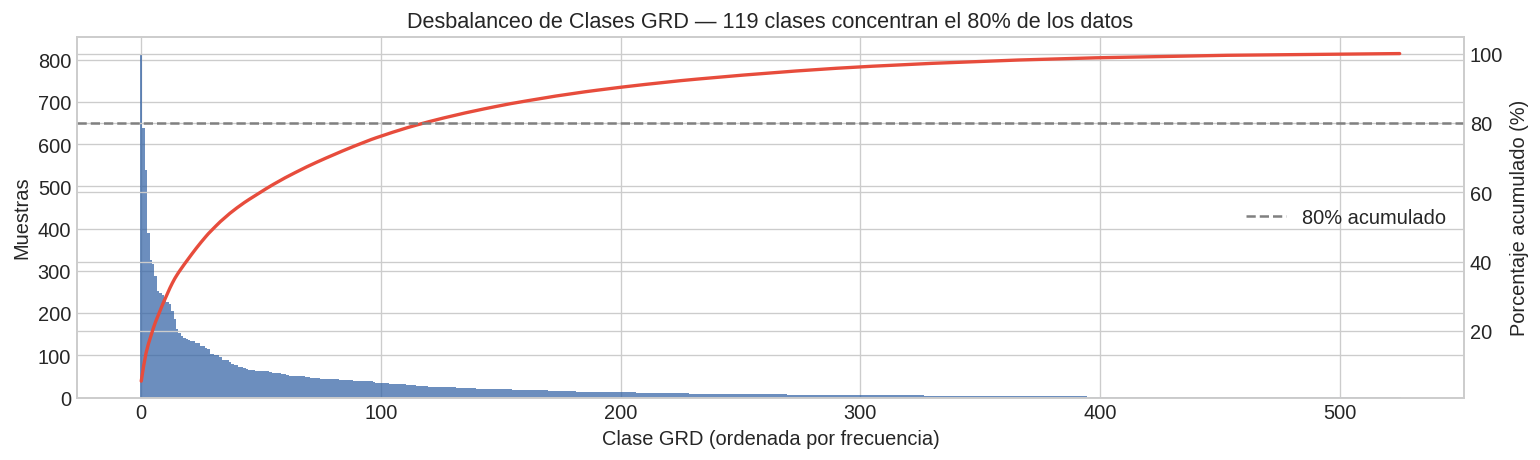

119 de 526 clases concentran el 80% de los datos


In [122]:
# Visualización del desbalanceo de clases
cumulative_pct = grd_counts.cumsum() / grd_counts.sum() * 100
top_n_80 = (cumulative_pct < 80).sum() + 1  # clases que acumulan el 80%

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(n_classes), grd_counts.values, color=PALETTE['primary'], alpha=0.7, width=1.0)
ax2 = ax.twinx()
ax2.plot(range(n_classes), cumulative_pct.values, color=PALETTE['secondary'], linewidth=2)
ax2.axhline(80, color='gray', ls='--', label='80% acumulado')
ax2.set_ylabel('Porcentaje acumulado (%)')
ax.set_xlabel('Clase GRD (ordenada por frecuencia)')
ax.set_ylabel('Muestras')
ax.set_title(f'Desbalanceo de Clases GRD — {top_n_80} clases concentran el 80% de los datos')
ax2.legend(loc='center right')
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/05_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"{top_n_80} de {n_classes} clases concentran el 80% de los datos")

---
## Sección 7 — Extracción y Análisis de Códigos ICD

In [123]:
# Recolectar todos los códigos
all_diag_codes = []
for col in diagnosis_cols:
    all_diag_codes.extend(df[col].apply(extract_icd_code).dropna().tolist())

all_proc_codes = []
for col in procedure_cols:
    all_proc_codes.extend(df[col].apply(extract_icd_code).dropna().tolist())

diag_freq = pd.Series(all_diag_codes).value_counts()
proc_freq = pd.Series(all_proc_codes).value_counts()

print(f"Códigos ICD-10 únicos     : {diag_freq.nunique():,}")
print(f"Códigos ICD-9 únicos      : {proc_freq.nunique():,}")
print(f"Top 10 diagnósticos = {diag_freq.head(10).sum() / len(all_diag_codes) * 100:.1f}% de ocurrencias")
print(f"Top 10 procedimientos = {proc_freq.head(10).sum() / len(all_proc_codes) * 100:.1f}% de ocurrencias")

Códigos ICD-10 únicos     : 240
Códigos ICD-9 únicos      : 204
Top 10 diagnósticos = 25.2% de ocurrencias
Top 10 procedimientos = 40.3% de ocurrencias


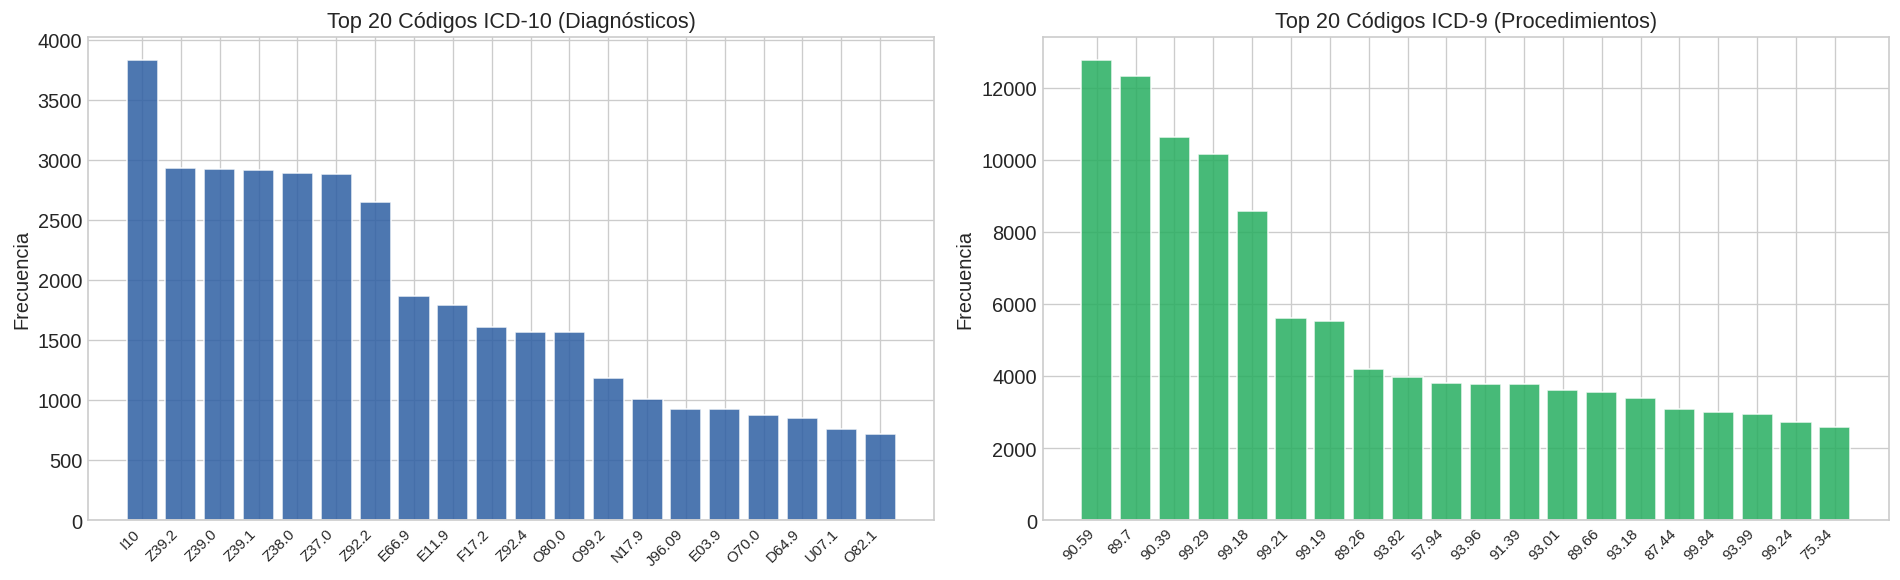

Guardado: assets/images/06_icd_codes.png


In [124]:
# Visualizaciones de códigos ICD
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, freq, title, color in [
    (axes[0], diag_freq, 'Top 20 Códigos ICD-10 (Diagnósticos)', PALETTE['primary']),
    (axes[1], proc_freq, 'Top 20 Códigos ICD-9 (Procedimientos)', PALETTE['accent']),
]:
    top20 = freq.head(20)
    ax.bar(range(20), top20.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_xticks(range(20))
    ax.set_xticklabels(top20.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(title); ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/06_icd_codes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: {IMAGES_DIR}/06_icd_codes.png")

___
# Sección 8 — Vista previa de features para el modelo


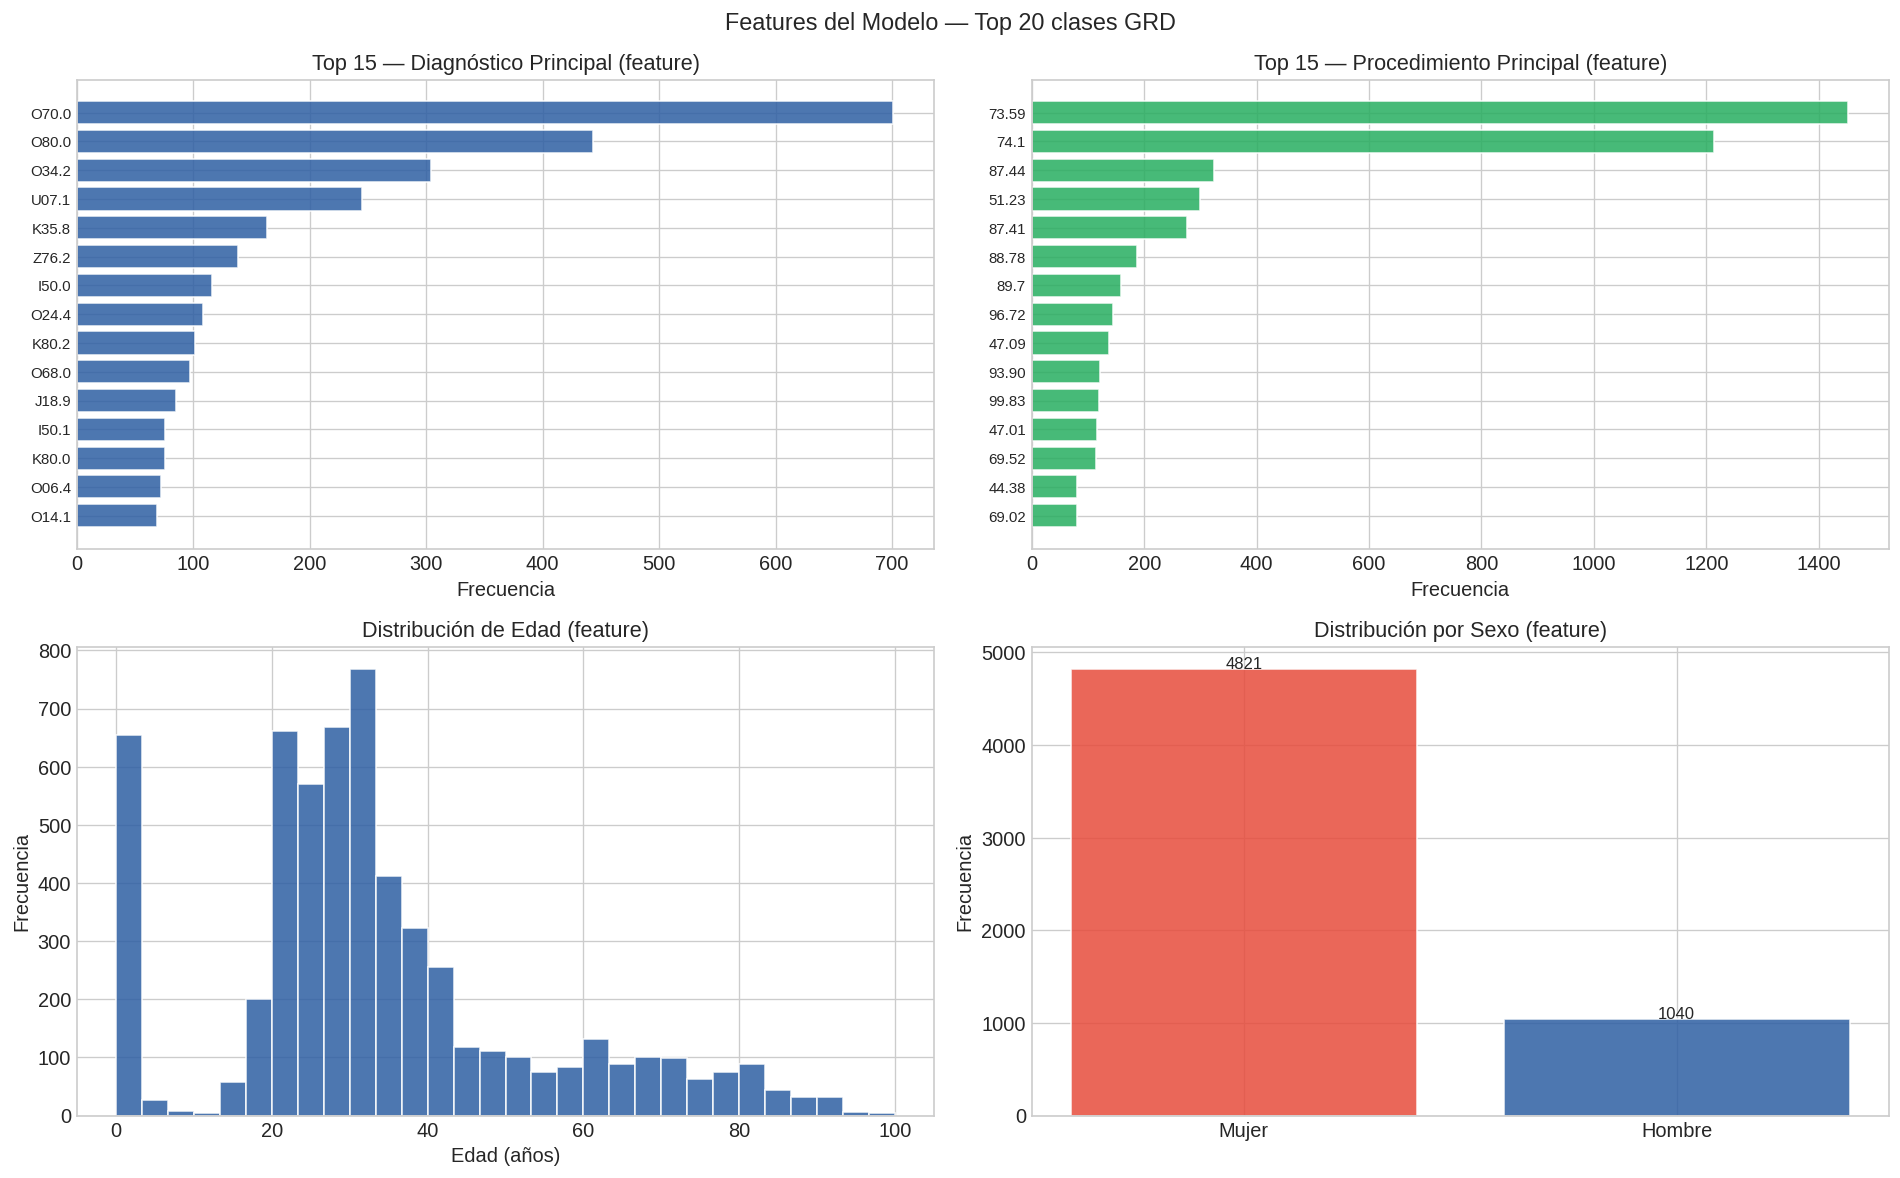

Guardado: assets/images/07_features_modelo.png


In [125]:
# Features a usar: Diag 01, Proced 01, Edad, Sexo
TOP_N_CLASSES = 20  # ajustar según lo que se usará en el modelo

df_model = df[df['GRD'].isin(df['GRD'].value_counts().head(TOP_N_CLASSES).index)].copy()
df_model['diag_principal'] = df_model[diagnosis_cols[0]].apply(extract_icd_code).fillna('MISSING')
df_model['proc_principal'] = df_model[procedure_cols[0]].apply(extract_icd_code).fillna('MISSING')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top 15 diagnósticos principales
top_diag = df_model['diag_principal'].value_counts().head(15)
axes[0, 0].barh(range(len(top_diag)), top_diag.values,
                color=PALETTE['primary'], alpha=0.85, edgecolor='white')
axes[0, 0].set_yticks(range(len(top_diag)))
axes[0, 0].set_yticklabels(top_diag.index, fontsize=9)
axes[0, 0].invert_yaxis()
axes[0, 0].set_title('Top 15 — Diagnóstico Principal (feature)')
axes[0, 0].set_xlabel('Frecuencia')

# Top 15 procedimientos principales
top_proc = df_model['proc_principal'].value_counts().head(15)
axes[0, 1].barh(range(len(top_proc)), top_proc.values,
                color=PALETTE['accent'], alpha=0.85, edgecolor='white')
axes[0, 1].set_yticks(range(len(top_proc)))
axes[0, 1].set_yticklabels(top_proc.index, fontsize=9)
axes[0, 1].invert_yaxis()
axes[0, 1].set_title('Top 15 — Procedimiento Principal (feature)')
axes[0, 1].set_xlabel('Frecuencia')

# Distribución de edad
axes[1, 0].hist(df_model['Edad en años'].dropna(), bins=30,
                color=PALETTE['primary'], edgecolor='white', alpha=0.85)
axes[1, 0].set_title('Distribución de Edad (feature)')
axes[1, 0].set_xlabel('Edad (años)')
axes[1, 0].set_ylabel('Frecuencia')

# Distribución por sexo
sex_counts = df_model['Sexo (Desc)'].value_counts()
axes[1, 1].bar(sex_counts.index, sex_counts.values,
               color=[PALETTE['secondary'], PALETTE['primary']], alpha=0.85, edgecolor='white')
axes[1, 1].set_title('Distribución por Sexo (feature)')
axes[1, 1].set_ylabel('Frecuencia')
for i, (cat, val) in enumerate(sex_counts.items()):
    axes[1, 1].text(i, val + 5, str(val), ha='center', fontsize=10)

plt.suptitle(f'Features del Modelo — Top {TOP_N_CLASSES} clases GRD', fontsize=14)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/07_features_modelo.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: {IMAGES_DIR}/07_features_modelo.png")

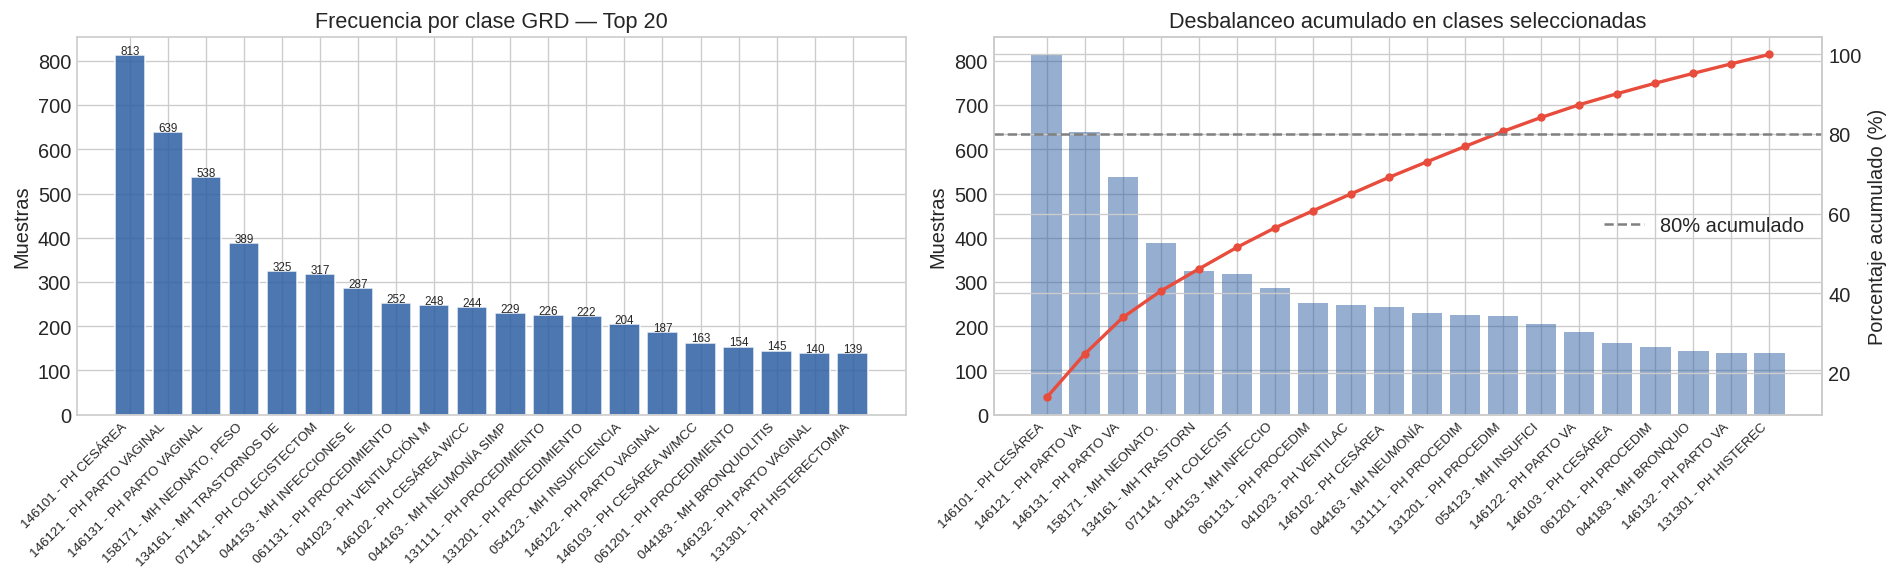

Guardado: assets/images/08_desbalanceo_top_clases.png


In [126]:
# Desbalanceo real sobre el subconjunto de clases del modelo
grd_top = df_model['GRD'].value_counts()
cumulative_pct = grd_top.cumsum() / grd_top.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barras de frecuencia por clase
axes[0].bar(range(len(grd_top)), grd_top.values,
            color=PALETTE['primary'], alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(len(grd_top)))
axes[0].set_xticklabels([g[:25] for g in grd_top.index],
                         rotation=45, ha='right', fontsize=8)
axes[0].set_title(f'Frecuencia por clase GRD — Top {TOP_N_CLASSES}')
axes[0].set_ylabel('Muestras')
for i, val in enumerate(grd_top.values):
    axes[0].text(i, val + 2, str(val), ha='center', fontsize=7)

# Curva de desbalanceo acumulado
ax2 = axes[1].twinx()
axes[1].bar(range(len(grd_top)), grd_top.values,
            color=PALETTE['primary'], alpha=0.5, width=0.8)
ax2.plot(range(len(grd_top)), cumulative_pct.values,
         color=PALETTE['secondary'], linewidth=2, marker='o', markersize=4)
ax2.axhline(80, color='gray', ls='--', label='80% acumulado')
axes[1].set_xticks(range(len(grd_top)))
axes[1].set_xticklabels([g[:20] for g in grd_top.index],
                         rotation=45, ha='right', fontsize=8)
axes[1].set_title('Desbalanceo acumulado en clases seleccionadas')
axes[1].set_ylabel('Muestras')
ax2.set_ylabel('Porcentaje acumulado (%)')
ax2.legend(loc='center right')

plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/08_desbalanceo_top_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Guardado: {IMAGES_DIR}/08_desbalanceo_top_clases.png")